In [1]:
from scripts.utils import plot_episode_history_v2
from scripts.variable_leverage_env_3 import agentDLVEnvV3
from torch_model_v3 import reccurentActor
import pandas as pd
import numpy as np

In [2]:
model = reccurentActor()
model.set_initial_state('actor_weights_v3.pth')

In [3]:
WIDTH = 0.4
TOP_LEVERAGE = 2 + WIDTH/2
BOTTOM_LEVERAGE = 2 - WIDTH/2

df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
doing nothing 80.85945609300394 %
action 1 5.6674278596636904 %
action 2 6.622379074112518 %
action 3 6.850736973219846 %


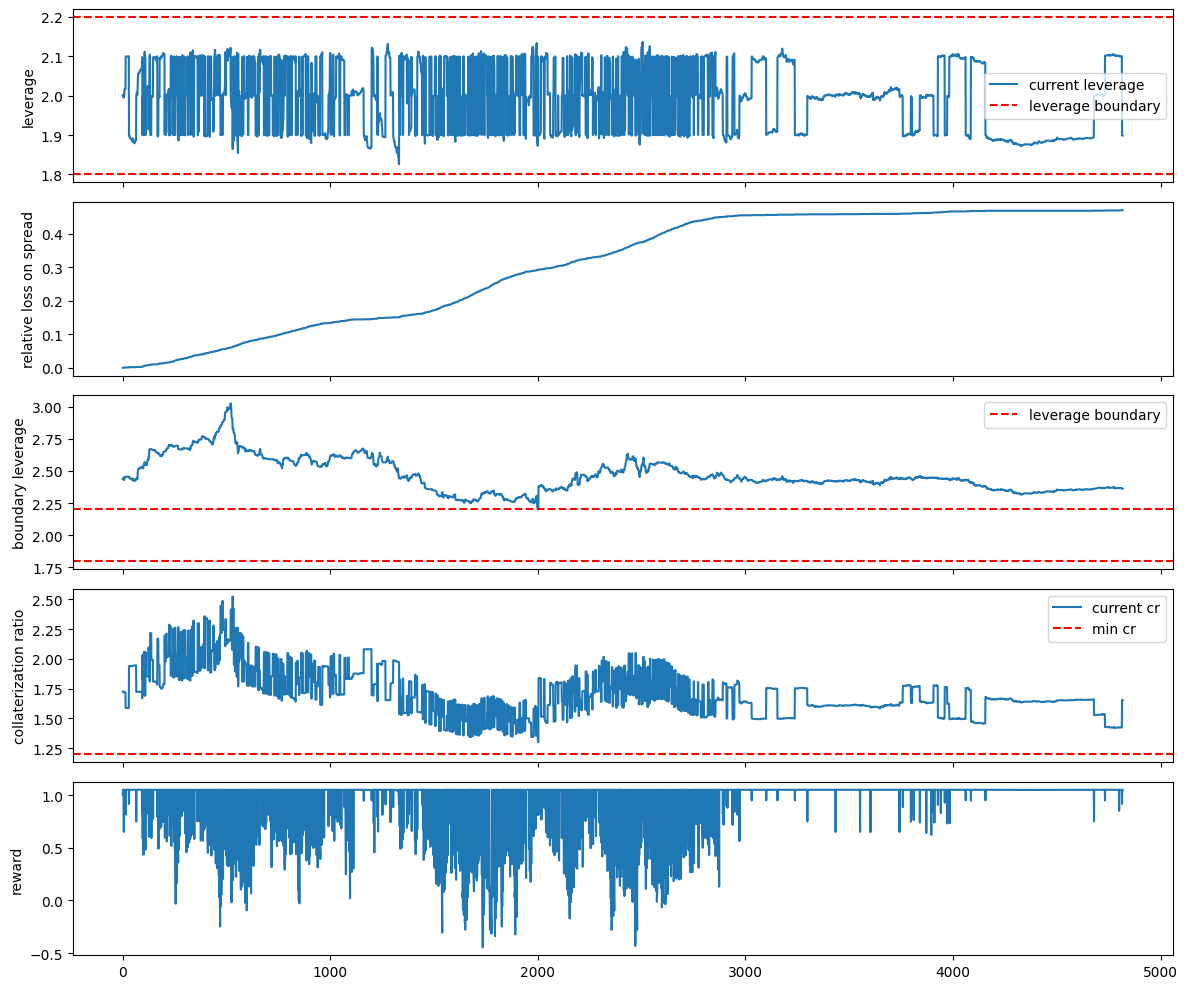

In [4]:
eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = True,
    is_reversed = True,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset()
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    #print(obs)
    action, log_prob, _, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

history = info['episode_history']
history_metrics = info['episode_metrics']
economic_metrics = info['episode_economics']
t_l = info['top leverage']
b_l = info['bottom leverage']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

plot_episode_history_v2(history, t_l, b_l)


In [5]:
eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = True,
    is_mixed = True,
    is_reversed = True,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset()
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action, log_prob, _, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

print(info['loss_rate'])

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
0.00014449318876756786


In [6]:
def naiveAgent(obs, min_cr=1.2, eps=1e-9):
    leverage = obs[0]
    cr = 1/obs[1]

    if cr <= min_cr + 0.03:
        return 1
    if leverage >= 0.95 or leverage <= 0.05:
        return 1
    else:
        return 0

eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = True,
    is_mixed = True,
    is_reversed = True,
    index=True,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset(seed=400)
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action, log_prob, _, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

a1 = info['loss_rate']
loss1 = info['losses']

obs, _ = eval_env.reset(seed=400)
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

a2 = info['loss_rate']
loss2 = info['losses']

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
Env True rng test: 0.1990988109705989
Env True rng test: 0.1990988109705989


model loss rate 713.3278756019362
mechanical agent loss rate 4.280158919733033


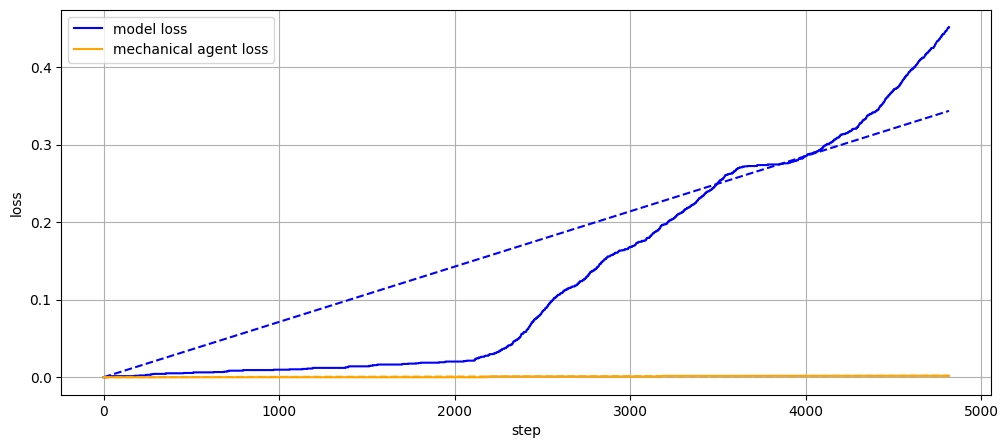

In [7]:
import matplotlib.pyplot as plt

time = np.arange(len(info['losses']))

print('model loss rate', a1*1e7)
print('mechanical agent loss rate', a2*1e7)

plt.figure(figsize=(12, 5))
plt.plot(time, loss1, color = 'blue', label = 'model loss')
plt.plot(time, time*a1, linestyle='--', color = 'blue')
plt.plot(time, loss2, color = 'orange', label = 'mechanical agent loss')
plt.plot(time, time*a2, linestyle='--', color = 'orange')
plt.legend()
plt.xlabel('step')
plt.ylabel('loss')
plt.grid(True)
plt.show()